<a href="https://colab.research.google.com/github/Abhishek213-013/Gesture_Transformer_Model/blob/main/Gesture_Transformer_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn joblib

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

**Extract ZIP Dataset**

In [3]:
import zipfile

zip_path = "/content/initial_data.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


**Check Gesture Folders**

In [4]:
base_path = "/content/dataset/data"

print(os.listdir(base_path))

['right', 'down', 'up', 'left']


**Load Dataset (Without Time Column)**

In [5]:
X = []
y = []
label_map = {}

window_size = 50
label_index = 0

for gesture_name in os.listdir(base_path):

    gesture_folder = os.path.join(base_path, gesture_name)

    if not os.path.isdir(gesture_folder):
        continue

    label_map[label_index] = gesture_name

    print(f"Loading Gesture: {gesture_name}")

    for file in os.listdir(gesture_folder):

        if file.endswith('.csv'):

            file_path = os.path.join(gesture_folder, file)

            df = pd.read_csv(file_path)

            # Remove time column
            if 'time' in df.columns:
                df = df.drop(columns=['time'])

            # Keep numeric values only
            df = df.select_dtypes(include=[np.number])

            data = df.values

            # Fixed window size
            if len(data) >= window_size:

                data = data[:window_size]

                X.append(data)
                y.append(label_index)

    label_index += 1

X = np.array(X)
y = np.array(y)

print()
print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)
print()
print("Label Map:")
print(label_map)

Loading Gesture: right
Loading Gesture: down
Loading Gesture: up
Loading Gesture: left

Dataset Shape: (101, 50, 12)
Labels Shape: (101,)

Label Map:
{0: 'right', 1: 'down', 2: 'up', 3: 'left'}


**Normalize Dataset**

In [6]:
from sklearn.preprocessing import StandardScaler

samples, timesteps, features = X.shape

X_reshaped = X.reshape(-1, features)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(samples, timesteps, features)

print("Normalization Complete")

Normalization Complete


**Split Train/Test Data**

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

num_classes = len(label_map)

y_cat = to_categorical(y, num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (80, 50, 12)
Testing Shape: (21, 50, 12)


**Build Transformer Encoder Block**

In [8]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.models import Model


def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):

    # Attention
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    res = x + inputs

    # Feed Forward
    x = Dense(ff_dim, activation='relu')(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)

    x = LayerNormalization(epsilon=1e-6)(x)

    return x + res

**Build Full Transformer Model**

In [9]:
inputs = Input(shape=(50, 12))

x = transformer_encoder(
    inputs,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.3
)

x = transformer_encoder(
    x,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.3
)

x = GlobalAveragePooling1D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 12)    │     13,068 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 12)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 12)    │         24 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 12)    │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 128)   │      1,664 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50, 12)    │      1,548 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 12)    │         24 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 12)    │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 12)    │     13,068 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 50, 12)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 12)    │         24 │ dropout_4[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 12)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50, 128)   │      1,664 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 50, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50, 12)    │      1,548 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 12)    │         24 │ dense_3[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 50, 12)    │          0 │ layer_normalizat… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 42,836 (167.33 KB)

 Trainable params: 42,836 (167.33 KB)

 Non-trainable params: 0 (0.00 B)

**Add EarlyStopping**

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**Train the Transformer Model**

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 597ms/step - accuracy: 0.3500 - loss: 1.3882 - val_accuracy: 0.5238 - val_loss: 1.0295
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 1.0606 - val_accuracy: 0.9048 - val_loss: 0.7052
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7250 - loss: 0.7970 - val_accuracy: 0.9048 - val_loss: 0.4484
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9500 - loss: 0.4636 - val_accuracy: 0.9048 - val_loss: 0.3169
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9375 - loss: 0.2731 - val_accuracy: 0.9048 - val_loss: 0.2919
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9625 - loss: 0.1894 - val_accuracy: 0.9048 - val_loss: 0.3137
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0847 - val_accuracy: 0.9048 - val_loss: 0.3122
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0519 - val_accuracy: 0.9048 - val_loss: 0.345

**Plot Accuracy Graph**

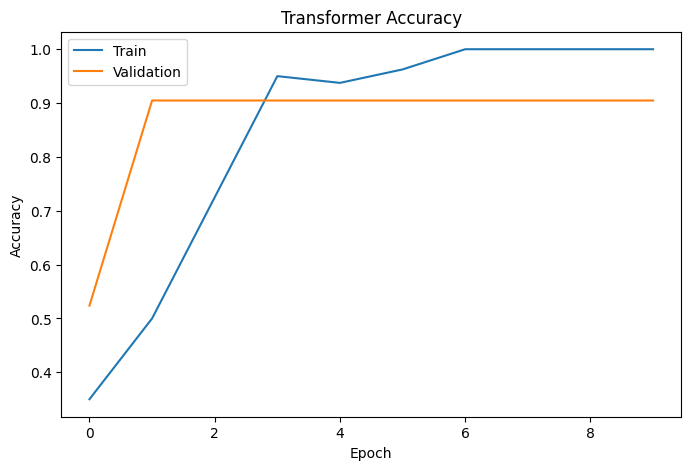

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Transformer Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

**Plot Loss Graph**

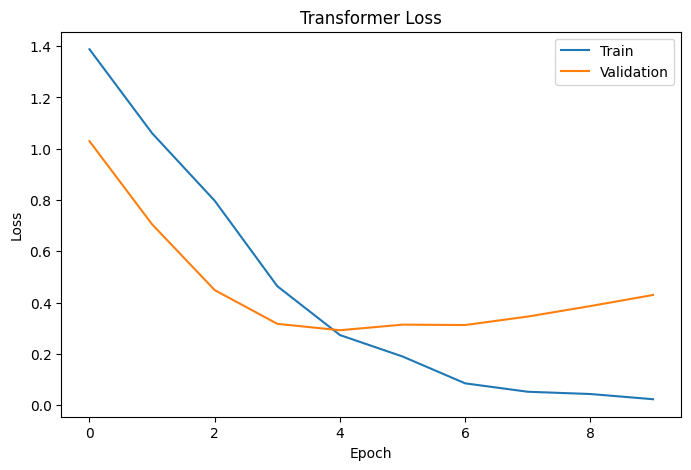

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Transformer Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

**Evaluate Model**

In [14]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9048 - loss: 0.2919
Test Accuracy: 0.9047619104385376
Test Loss: 0.291923850774765


**Generate Predictions**

In [15]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step


**Confusion Matrix**

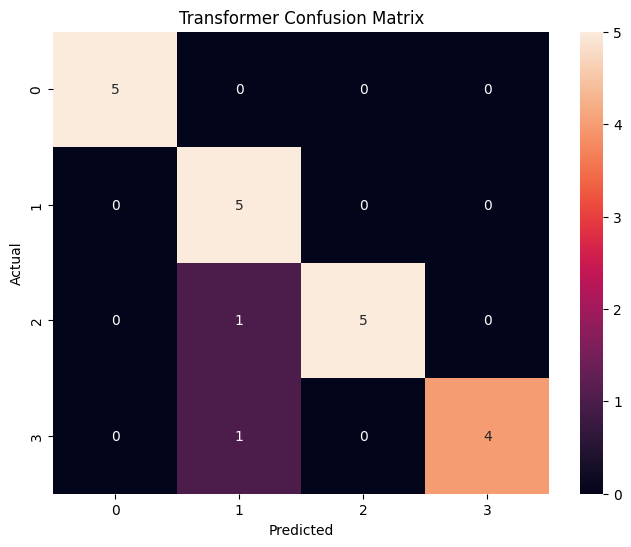

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Transformer Confusion Matrix')

plt.show()

**Classification Report**

In [17]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.71      1.00      0.83         5
           2       1.00      0.83      0.91         6
           3       1.00      0.80      0.89         5

    accuracy                           0.90        21
   macro avg       0.93      0.91      0.91        21
weighted avg       0.93      0.90      0.91        21



**Save the Model**

In [18]:
model.save("transformer_gesture_model.h5")

print("Transformer Model Saved Successfully")

Transformer Model Saved Successfully


**Save the Scaler**

In [19]:
import joblib

joblib.dump(scaler, 'transformer_scaler.save')

print("Scaler Saved Successfully")

Scaler Saved Successfully
